In [1]:
# ============================================================
# LIBRARIAT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, geom

# Lexo dataset-in e pastruar
df = pd.read_csv("../data/processed/laliga_master.csv")

print("Dimensionet:", df.shape)
print("OK!")

Dimensionet: (420, 33)
OK!


In [3]:
# ============================================================
# GJEOMETRIKA — Sa sezone deri në titullin e ardhshëm?
# ============================================================

# Probabilitetet historike
p_barcelona  = 12 / 21
p_realmadrid =  7 / 21
p_atletico   =  2 / 21

# P(X = k) — probabiliteti që titulli të vijë në sezonin k
k_vlerat = list(range(1, 11))  # 1 deri 10 sezone

prob_geo_barca = [geom.pmf(k, p_barcelona)  for k in k_vlerat]
prob_geo_rm    = [geom.pmf(k, p_realmadrid) for k in k_vlerat]
prob_geo_atl   = [geom.pmf(k, p_atletico)   for k in k_vlerat]

print("=== P(X=k) — Titulli vjen në sezonin k ===")
print(f"{'k':>3} {'Barcelona':>12} {'Real Madrid':>12} {'Atletico':>12}")
for k in k_vlerat:
    print(f"{k:>3} {prob_geo_barca[k-1]:>12.4f} "
          f"{prob_geo_rm[k-1]:>12.4f} "
          f"{prob_geo_atl[k-1]:>12.4f}")

# Mesatarja — sezoni i pritshëm i titullit
print(f"\n=== SEZONI I PRITSHËM I TITULLIT ===")

=== P(X=k) — Titulli vjen në sezonin k ===
  k    Barcelona  Real Madrid     Atletico
  1       0.5714       0.3333       0.0952
  2       0.2449       0.2222       0.0862
  3       0.1050       0.1481       0.0780
  4       0.0450       0.0988       0.0705
  5       0.0193       0.0658       0.0638
  6       0.0083       0.0439       0.0577
  7       0.0035       0.0293       0.0522
  8       0.0015       0.0195       0.0473
  9       0.0007       0.0130       0.0428
 10       0.0003       0.0087       0.0387

=== SEZONI I PRITSHËM I TITULLIT ===


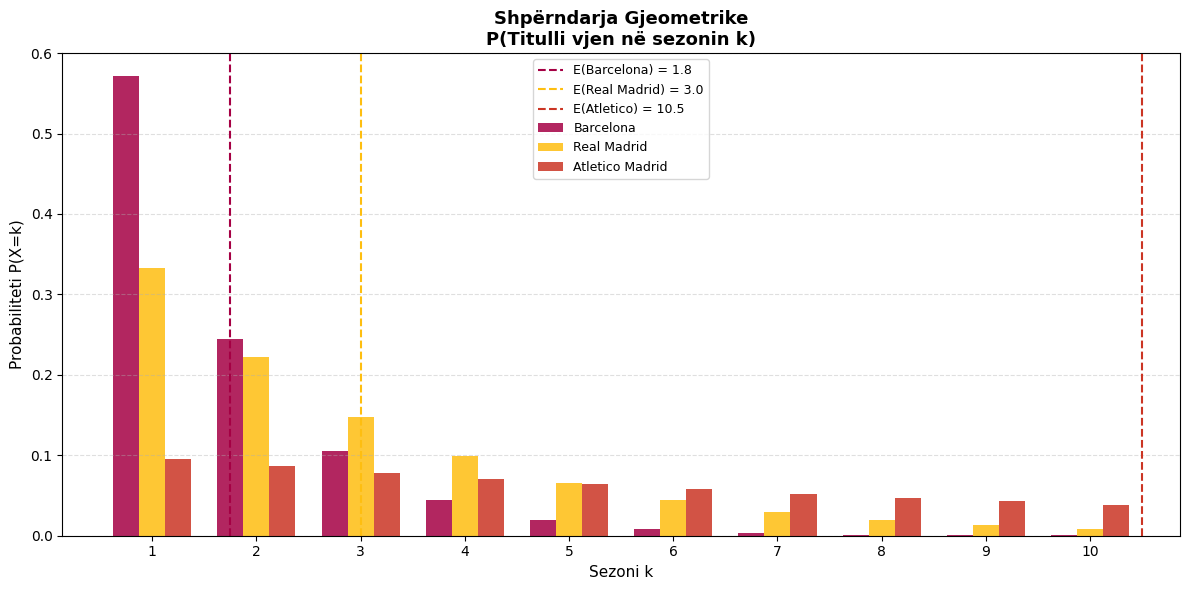

Grafiku u ruajt!


In [4]:
# ============================================================
# GRAFIKU - GJEOMETRIKA
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x     = np.array(k_vlerat)
width = 0.25

ax.bar(x - width, prob_geo_barca, width,
       color="#A50044", label="Barcelona",       alpha=0.85)
ax.bar(x,          prob_geo_rm,   width,
       color="#FEBE10", label="Real Madrid",     alpha=0.85)
ax.bar(x + width,  prob_geo_atl,  width,
       color="#CB3524", label="Atletico Madrid", alpha=0.85)

ax.set_xlabel("Sezoni k", fontsize=11)
ax.set_ylabel("Probabiliteti P(X=k)", fontsize=11)
ax.set_title("Shpërndarja Gjeometrike\nP(Titulli vjen në sezonin k)",
             fontsize=13, fontweight="bold")
ax.set_xticks(k_vlerat)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Shto mesataret
ax.axvline(x=1/p_barcelona,  color="#A50044", linestyle="--", linewidth=1.5,
           label=f"E(Barcelona) = {1/p_barcelona:.1f}")
ax.axvline(x=1/p_realmadrid, color="#FEBE10", linestyle="--", linewidth=1.5,
           label=f"E(Real Madrid) = {1/p_realmadrid:.1f}")
ax.axvline(x=1/p_atletico,   color="#CB3524", linestyle="--", linewidth=1.5,
           label=f"E(Atletico) = {1/p_atletico:.1f}")

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/13_gjeometrika.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [5]:
# ============================================================
# POISSON — Probabiliteti i golave në një ndeshje
# ============================================================

# Mesatarja e golave per ndeshje per ekip
gola_mesatare = df.groupby("Squad")["GF"].mean() / 38

ekipet_kryesore = ["Barcelona", "Real Madrid", "Atletico Madrid",
                   "Sevilla", "Valencia", "Athletic Club"]

print("=== GOLA MESATARE PER NDESHJE ===")
for ekip in ekipet_kryesore:
    print(f"{ekip:25} λ = {gola_mesatare[ekip]:.3f}")

=== GOLA MESATARE PER NDESHJE ===
Barcelona                 λ = 2.445
Real Madrid               λ = 2.323
Atletico Madrid           λ = 1.623
Sevilla                   λ = 1.494
Valencia                  λ = 1.432
Athletic Club             λ = 1.284


In [6]:
# ============================================================
# POISSON — P(X=k gola) per ndeshje
# ============================================================

k_vlerat = list(range(0, 8))  # 0 deri 7 gola

print("=== P(X=k gola) per ndeshje ===")
print(f"{'k':>3} {'Barcelona':>12} {'Real Madrid':>12} {'Atletico':>12} {'Sevilla':>12}")

for k in k_vlerat:
    p_barca = poisson.pmf(k, gola_mesatare["Barcelona"])
    p_rm    = poisson.pmf(k, gola_mesatare["Real Madrid"])
    p_atl   = poisson.pmf(k, gola_mesatare["Atletico Madrid"])
    p_sev   = poisson.pmf(k, gola_mesatare["Sevilla"])
    print(f"{k:>3} {p_barca:>12.4f} {p_rm:>12.4f} {p_atl:>12.4f} {p_sev:>12.4f}")

=== P(X=k gola) per ndeshje ===
  k    Barcelona  Real Madrid     Atletico      Sevilla
  0       0.0867       0.0979       0.1973       0.2245
  1       0.2121       0.2276       0.3203       0.3354
  2       0.2592       0.2644       0.2599       0.2505
  3       0.2113       0.2047       0.1406       0.1247
  4       0.1291       0.1189       0.0570       0.0466
  5       0.0631       0.0553       0.0185       0.0139
  6       0.0257       0.0214       0.0050       0.0035
  7       0.0090       0.0071       0.0012       0.0007


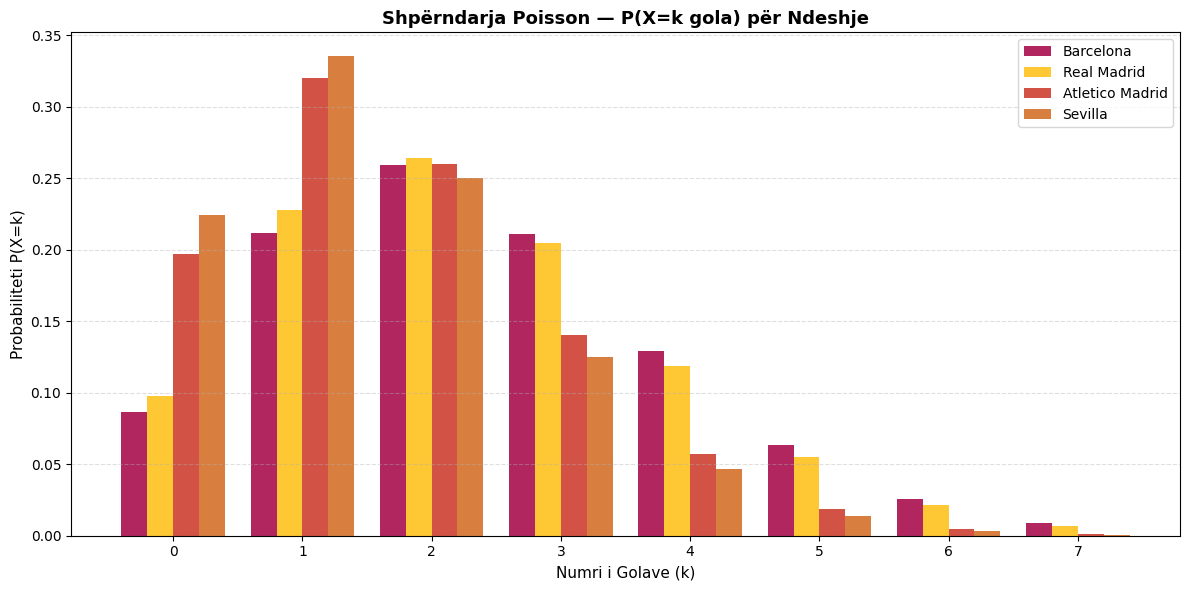

Grafiku u ruajt!


In [7]:
# ============================================================
# GRAFIKU - POISSON
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x     = np.array(k_vlerat)
width = 0.2

ax.bar(x - 1.5*width, [poisson.pmf(k, gola_mesatare["Barcelona"])  for k in k_vlerat],
       width, color="#A50044", label="Barcelona",       alpha=0.85)
ax.bar(x - 0.5*width, [poisson.pmf(k, gola_mesatare["Real Madrid"]) for k in k_vlerat],
       width, color="#FEBE10", label="Real Madrid",     alpha=0.85)
ax.bar(x + 0.5*width, [poisson.pmf(k, gola_mesatare["Atletico Madrid"]) for k in k_vlerat],
       width, color="#CB3524", label="Atletico Madrid", alpha=0.85)
ax.bar(x + 1.5*width, [poisson.pmf(k, gola_mesatare["Sevilla"]) for k in k_vlerat],
       width, color="#D2691E", label="Sevilla",         alpha=0.85)

ax.set_xlabel("Numri i Golave (k)", fontsize=11)
ax.set_ylabel("Probabiliteti P(X=k)", fontsize=11)
ax.set_title("Shpërndarja Poisson — P(X=k gola) për Ndeshje",
             fontsize=13, fontweight="bold")
ax.set_xticks(k_vlerat)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/14_poisson.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")